# GEMS code tour — one spectrum, every stage

This notebook traces a **single real FT-ICR spectrum** through the entire GEMS pipeline, printing the
shape/dtype of every tensor and visualizing the Δm graph, the denoising corruption, and the sparse
attention mask. It is both a learning aid and a debugging tool.

**The spine to keep in mind:** everything communicates through one *batch dict*. Each stage either
produces or consumes its keys (`mz`, `intensity`, `*_target`, `*_mask`, `valid_mask`, `replaced_label`,
`delta_edges`). The schema is summarized at the very end.

**Prereqs:** run top to bottom. **Select the kernel whose Python has `gems` + `pyc2mc` installed**
(here: the conda base / `python3` kernel) — use VS Code's kernel picker at the top-right. Needs the
local corpus under `data/walking_calibrated_pks/`. The setup cell adds the repo root to `sys.path`,
so `import gems` works even without `pip install -e .`.

In [1]:
import warnings, math, collections, sys
from pathlib import Path
import numpy as np
import torch

warnings.filterwarnings("ignore")
torch.manual_seed(0)

# Make `import gems` work regardless of how the kernel was launched: walk up from the
# working dir to the repo root (the folder containing gems/), and put it on sys.path.
def _find_repo_root(start: Path) -> Path:
    for cand in (start.resolve(), *start.resolve().parents):
        if (cand / "gems" / "__init__.py").exists():
            return cand
    return start.resolve()

REPO = _find_repo_root(Path.cwd())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import gems
print("python :", sys.executable)
print("gems   :", gems.__file__)

# pyc2mc (the .pks reader / chemistry backend) must be installed in THIS kernel's env.
try:
    import pyc2mc  # noqa: F401
except ModuleNotFoundError as e:
    raise RuntimeError(
        "pyc2mc is not installed in this kernel. Pick the Jupyter kernel whose Python has "
        "gems + pyc2mc (here: the conda base env / 'python3' kernel at "
        "/Users/tejapotu/miniconda3). In VS Code use the kernel picker at the top-right of "
        "the notebook; on a fresh clone, `pip install -e .` and the pyc2mc backend first."
    ) from e

PKS_DIR = REPO / "data" / "walking_calibrated_pks"
pks_files = sorted(PKS_DIR.glob("*.pks"))
print("repo   :", REPO)
print("n .pks :", len(pks_files), "| hero:", pks_files[0].name)

try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except Exception:
    HAVE_PLT = False
    print("(matplotlib unavailable — plots skipped)")

python : /Users/tejapotu/miniconda3/bin/python
gems   : /Users/tejapotu/School/Projects/LLM/GEMS/gems/__init__.py
repo   : /Users/tejapotu/School/Projects/LLM/GEMS
n .pks : 272 | hero: 1_LCMSnegESI_S1F4_coadded_1515-1563_filtered_wc.pks


## Stage 1 — read `.pks` → `SpectrumRecord`

`gems.data.peaklist.load_record` is a thin wrapper over pyc2mc's `.pks` reader. It returns a
`SpectrumRecord`: plain numpy arrays (`mz`, `intensity`, `sn`, …) plus ion mode and metadata. This is
the only place raw IO happens — everything downstream is numpy/torch.

In [2]:
from gems.data.peaklist import load_record

rec = load_record(str(pks_files[0]))
print("type      :", type(rec).__name__)
print("n_peaks   :", len(rec))
print("ion_mode  :", rec.ion_mode.value)
print("mz range  :", round(float(rec.mz.min()), 3), "→", round(float(rec.mz.max()), 3))
print("mz array  :", rec.mz.dtype, rec.mz.shape)
print("intensity :", rec.intensity.dtype, "min", float(rec.intensity.min()), "max", float(rec.intensity.max()))

type      : SpectrumRecord
n_peaks   : 21093
ion_mode  : negative
mz range  : 200.072 → 1198.241
mz array  : float64 (21093,)
intensity : float64 min 1117184.0 max 338690048.0


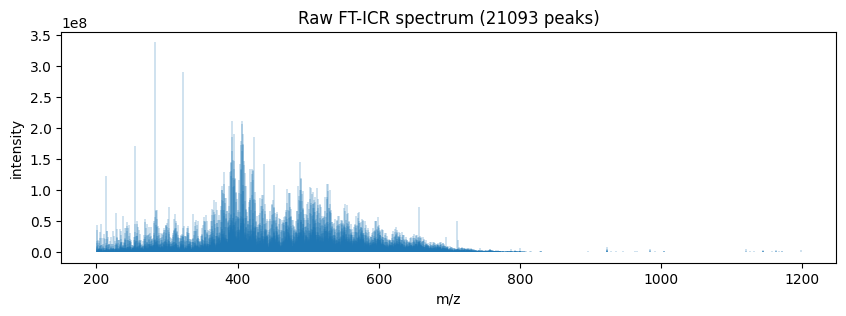

In [3]:
if HAVE_PLT:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.vlines(rec.mz, 0, rec.intensity, lw=0.3)
    ax.set(xlabel="m/z", ylabel="intensity", title=f"Raw FT-ICR spectrum ({len(rec)} peaks)")
    plt.show()

## Stage 2 — the building-block Δm vocabulary

`DeltaVocabulary.from_seeds()` gives the known building blocks (CH2, O, S, CF2, …) with exact masses.
Two things to notice for later:

- **`match(Δm)`** returns the nearest block within a ppm window (or `None`).
- One **reserved row past the real blocks** is the `[masked-edge]` sentinel (`masked_edge_index`), used
  by the leakage guard. That's why the edge-bias table has `n_embeddings = len + 1` rows.
- Seed weights are all **0** — abundance weighting only turns on once `build_vocabulary_from_corpus`
  lands, so right now the graph attention runs as a pure sparse mask.

In [4]:
from gems.vocab.vocabulary import DeltaVocabulary

vocab = DeltaVocabulary.from_seeds(include_c13=True)
print("n blocks            :", len(vocab))
print("n_embeddings        :", vocab.n_embeddings, "(real blocks + [masked-edge] sentinel)")
print("masked_edge_index   :", vocab.masked_edge_index)
print()
for name in vocab.names:
    print(f"  idx {vocab.index_of(name):2d}  {name:5s}  Δm={vocab.masses[name]:9.5f} Da   weight={vocab.weights.get(name, 0.0)}")
print()
print("match(14.01565) ->", vocab.match(14.01565), "   # CH2")
print("match(13.97900) ->", vocab.match(13.97900), "   # matches nothing")

n blocks            : 13
n_embeddings        : 14 (real blocks + [masked-edge] sentinel)
masked_edge_index   : 13

  idx  0  C13    Δm=  1.00335 Da   weight=0.0
  idx  1  H2     Δm=  2.01565 Da   weight=0.0
  idx  2  N      Δm= 14.00307 Da   weight=0.0
  idx  3  CH2    Δm= 14.01565 Da   weight=0.0
  idx  4  O      Δm= 15.99491 Da   weight=0.0
  idx  5  H2O    Δm= 18.01056 Da   weight=0.0
  idx  6  CHN    Δm= 27.01090 Da   weight=0.0
  idx  7  CO     Δm= 27.99491 Da   weight=0.0
  idx  8  CH2O   Δm= 30.01056 Da   weight=0.0
  idx  9  S      Δm= 31.97207 Da   weight=0.0
  idx 10  CO2    Δm= 43.98983 Da   weight=0.0
  idx 11  COOH   Δm= 44.99765 Da   weight=0.0
  idx 12  CF2    Δm= 49.99681 Da   weight=0.0

match(14.01565) -> CH2    # CH2
match(13.97900) -> None    # matches nothing


## Stage 3 — `DataFormat`: variable-length spectrum → fixed `(max_peaks,)` arrays

FT-ICR spectra have thousands of peaks; attention needs a fixed token count. `DataFormat`:
**select** ≤ `max_peaks` peaks (here via the simple `TopNAbundance` sanity selector) → **normalize**
intensity to [0,1] → **pad** to `max_peaks`. `valid_mask` marks the real (non-pad) positions.

In [5]:
from gems.data.dformats import DataFormat
from gems.data.peak_selection import TopNAbundance

df = DataFormat(max_peaks=256, max_mz=1500.0, log_intensity=True)
selector = TopNAbundance()          # the sanity selector; graph-induced is compared just below
item = df(rec, selector)
for k, v in item.items():
    print(f"  {k:12s} shape={v.shape} dtype={v.dtype}")
n_valid = int(item["valid_mask"].sum())
print(f"\nselected {n_valid} of {len(rec)} peaks; intensity now in [0, 1]")

  mz           shape=(256,) dtype=float32
  intensity    shape=(256,) dtype=float32
  valid_mask   shape=(256,) dtype=bool

selected 256 of 21093 peaks; intensity now in [0, 1]


In [6]:
# The LOCKED selector is graph-induced: keep peaks that sit on >=1 abundant Δm edge.
from gems.data.peak_selection import GraphInduced

gi = GraphInduced(vocab=vocab, ppm_tol=1.0, degree_cap=32)
gi_idx = gi.select(rec, 256)
print("TopNAbundance : keeps the 256 most abundant peaks (sanity floor)")
print(f"GraphInduced  : keeps {len(gi_idx)} peaks that participate in Δm relationships (locked path)")

TopNAbundance : keeps the 256 most abundant peaks (sanity floor)
GraphInduced  : keeps 256 peaks that participate in Δm relationships (locked path)


## Stage 4 — the per-spectrum Δm graph

`build_delta_graph` compares every selected peak pair, matches the difference to a building block
within a ppm window, tags the edge with `(block_idx, abundance weight)`, and applies a **degree cap**
(top-k edges per node). The result drives *both* the attention mask and the edge bias.

The degree-distribution plot below is exactly the "measure first" step `BUILD_PLAN.md` Part C asks for
before locking `k`/`d`/`L`.

In [7]:
from gems.vocab.graph import build_delta_graph

mz_sel = item["mz"][item["valid_mask"]].astype(np.float64)   # the real selected peaks
edges = build_delta_graph(mz_sel, vocab, ppm_tol=1.0, degree_cap=32)
print("nodes (n_peaks)     :", edges.n_peaks)
print("edges               :", edges.src.size)
print("peaks on >=1 edge   :", int(edges.node_mask().sum()))
print("\nedges by building block:")
for name, c in collections.Counter(vocab.names[b] for b in edges.block_idx).most_common():
    print(f"  {name:5s}: {c}")

nodes (n_peaks)     : 256
edges               : 352
peaks on >=1 edge   : 221

edges by building block:
  O    : 89
  H2O  : 71
  CH2  : 63
  CO   : 56
  CH2O : 32
  CO2  : 27
  CHN  : 14


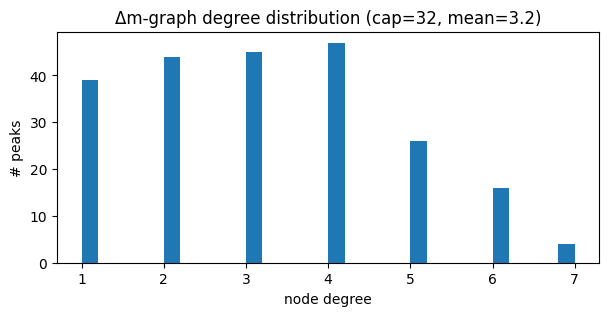

In [8]:
if HAVE_PLT and edges.src.size:
    deg = np.bincount(np.concatenate([edges.src, edges.dst]), minlength=edges.n_peaks)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(deg[deg > 0], bins=30)
    ax.set(xlabel="node degree", ylabel="# peaks",
           title=f"Δm-graph degree distribution (cap=32, mean={deg[deg>0].mean():.1f})")
    plt.show()

## Stage 5 — denoising corruption (the self-supervised target)

`SpectrumDenoisingDataset` wraps the fixed-size dataset and produces **one corrupted view** with three
disjoint corruptions + their targets, plus the leakage-guarded edges:

- **mz_mask** — blank the m/z (keep intensity); target = original mass.
- **int_mask** — blank the intensity (keep m/z); target = original intensity.
- **replaced** — swap in a plausible-but-wrong m/z; label the peak fake.

Crucially, edges are built on the **original** m/z, then edges touching a masked peak are stripped to
the `[masked-edge]` sentinel — so the model knows a masked peak is *related* to neighbors but never
*which* block links them (the FT-ICR leakage fix).

In [9]:
from gems.data.ms_data import MSData
from gems.data.masking import SpectrumDenoisingDataset

corpus = MSData(records=[load_record(str(f)) for f in pks_files[:2]])
base = corpus.to_torch_dataset(transform=lambda r: df(r, selector))
ds = SpectrumDenoisingDataset(base, mask_prob=0.30, replaced_fraction=0.15, vocab=vocab, seed=0)

sample = ds[0]
print("item keys:", list(sample.keys()))
print()
for k in ["mz_mask", "int_mask", "valid_mask", "replaced_label"]:
    print(f"  {k:14s} -> {int(sample[k].sum())} peaks")
print("\nragged per-spectrum edge tensors:")
for k in ["edge_src", "edge_dst", "edge_block", "edge_weight"]:
    print(f"  {k:12s} shape={tuple(sample[k].shape)} dtype={sample[k].dtype}")
sent = int((sample["edge_block"] == vocab.masked_edge_index).sum())
print(f"\nleakage guard: {sent} edges stripped to [masked-edge] sentinel (idx {vocab.masked_edge_index})")

item keys: ['mz', 'intensity', 'mz_target', 'intensity_target', 'mz_mask', 'int_mask', 'valid_mask', 'replaced_label', 'masked_nodes', 'edge_src', 'edge_dst', 'edge_block', 'edge_weight']

  mz_mask        -> 77 peaks
  int_mask       -> 23 peaks
  valid_mask     -> 256 peaks
  replaced_label -> 27 peaks

ragged per-spectrum edge tensors:
  edge_src     shape=(352,) dtype=torch.int64
  edge_dst     shape=(352,) dtype=torch.int64
  edge_block   shape=(352,) dtype=torch.int64
  edge_weight  shape=(352,) dtype=torch.float32

leakage guard: 180 edges stripped to [masked-edge] sentinel (idx 13)


In [10]:
mzc, mz0 = sample["mz"].numpy(), sample["mz_target"].numpy()
mm = sample["mz_mask"].numpy()
rr = sample["replaced_label"].numpy().astype(bool)
print("masked m/z (blanked to 0):")
print("   original:", np.round(mz0[mm][:4], 4), "-> corrupted:", np.round(mzc[mm][:4], 4))
print("replaced m/z (wrong but plausible):")
print("   original:", np.round(mz0[rr][:4], 4), "-> corrupted:", np.round(mzc[rr][:4], 4))

masked m/z (blanked to 0):
   original: [213.1398 283.2644 285.161  302.1763] -> corrupted: [0. 0. 0. 0.]
replaced m/z (wrong but plausible):
   original: [255.233  284.1293 311.0993 355.1665] -> corrupted: [256.4674 282.382  312.9623 357.7417]


## Stage 6 — `collate_spectra`: per-spectrum dicts → one batch

Fixed-size keys are stacked into `(B, N)`. The **ragged** per-spectrum edges are concatenated into a
single `delta_edges` dict with a `batch_idx` selector — this flat representation is what lets the
attention bias scatter each spectrum's edges into the right slice of the dense `(B, H, N, N)` logits.

In [11]:
from gems.data.datamodule import collate_spectra

batch = collate_spectra([ds[0], ds[1]])   # B = 2
print("fixed-size keys:")
for k, v in batch.items():
    if k != "delta_edges":
        print(f"  {k:14s} {tuple(v.shape)} {v.dtype}")
print("\ndelta_edges (ragged edges flattened across the batch):")
for k, v in batch["delta_edges"].items():
    print(f"  {k:10s} {tuple(v.shape)} {v.dtype}")
print("\nbatch_idx unique values:", batch["delta_edges"]["batch_idx"].unique().tolist(), "(one per spectrum)")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1


PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


fixed-size keys:
  mz             (2, 256) torch.float32
  intensity      (2, 256) torch.float32
  mz_target      (2, 256) torch.float32
  intensity_target (2, 256) torch.float32
  mz_mask        (2, 256) torch.bool
  int_mask       (2, 256) torch.bool
  valid_mask     (2, 256) torch.bool
  replaced_label (2, 256) torch.float32
  masked_nodes   (2, 256) torch.bool

delta_edges (ragged edges flattened across the batch):
  batch_idx  (519,) torch.int64
  src        (519,) torch.int64
  dst        (519,) torch.int64
  block_idx  (519,) torch.int64
  weight     (519,) torch.float32

batch_idx unique values: [0, 1] (one per spectrum)


## Stage 7 — `PeakTokenizer`: each peak → a `dim`-vector

Splits m/z into **nominal mass** (integer part → `nn.Embedding`) and **mass defect** (fractional part
→ MLP), adds a **log-intensity** embedding, sums, and LayerNorm's. No positional encoding — peaks are
a set; order comes only from the Δm graph.

In [12]:
from gems.models.layers.peak_tokenizer import PeakTokenizer

DIM = 64
tok = PeakTokenizer(dim=DIM, max_nominal=2000, use_fourier=False)
x = tok(batch["mz"], batch["intensity"])
print("tokens:", tuple(x.shape), " = (B, N, dim)")

tokens: (2, 256, 64)  = (B, N, dim)


## Stage 8 — the attention bias (the trickiest code)

`GraphDeltaBias.forward` does two things to the `(B, H, N, N)` QKᵀ logits:
1. **mask** — set every non-edge pair to `-inf` (keep the diagonal), so softmax zeroes them;
2. **bias** — scatter the learned, abundance-weighted per-block bias onto the surviving edges.

Because seed weights are 0, the bias term is currently neutral, so what you see below is the pure
**sparse Δm connectivity mask**. Notice how sparse it is vs the full `N×N`.

allowed attention pairs (spectrum 0): 960 / 65536 = 1.5%  (the rest are -inf)


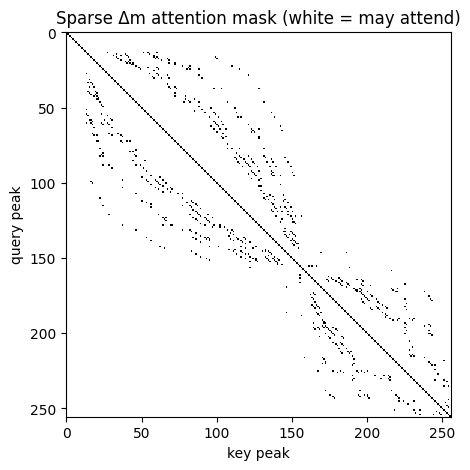

In [13]:
from gems.models.layers.attention_bias import GraphDeltaBias

gb = GraphDeltaBias(n_blocks=vocab.n_embeddings, n_heads=2)
B, N = batch["mz"].shape
biased = gb(torch.zeros(B, 2, N, N), batch["delta_edges"], N)

allowed = torch.isfinite(biased[0, 0])     # spectrum 0, head 0
print(f"allowed attention pairs (spectrum 0): {int(allowed.sum())} / {N*N} "
      f"= {100*allowed.float().mean():.1f}%  (the rest are -inf)")
if HAVE_PLT:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(allowed.numpy(), cmap="Greys", interpolation="nearest")
    ax.set(title="Sparse Δm attention mask (white = may attend)", xlabel="key peak", ylabel="query peak")
    plt.show()

## Stage 9 — the encoder

`DeltaTransformerEncoder` stacks pre-norm blocks (each running the biased self-attention above) and
ends with **attention-pooling**: a learned query scores each peak → a single whole-spectrum vector `z`.
Returns both the per-peak embeddings and the pooled `z`.

In [14]:
from gems.models.layers.transformer import DeltaTransformerEncoder

enc = DeltaTransformerEncoder(dim=DIM, n_layers=2, n_heads=2, attention_bias=gb, pooling="attention")
key_padding_mask = ~batch["valid_mask"]              # True == padding (ignored as a key)
peak_emb, pooled = enc(x, delta_edges=batch["delta_edges"], key_padding_mask=key_padding_mask)
print("peak_emb:", tuple(peak_emb.shape), " (per-peak)")
print("pooled  :", tuple(pooled.shape), " (whole-spectrum z)")

peak_emb: (2, 256, 64)  (per-peak)
pooled  : (2, 64)  (whole-spectrum z)


## Stage 10 — the denoising objective

Each channel gathers the relevant peak embeddings and predicts its target; `ℒ = ℒ_mz + λ_int·ℒ_int +
λ_rpd·ℒ_rpd`. A clean sanity check: each freshly-initialized channel sits near its random baseline
`ln(#classes)` — that's how you know a head is wired correctly.

In [15]:
from gems.models.objectives.denoising import SpectrumDenoising

obj = SpectrumDenoising(dim=DIM, max_mz=1500.0)
losses = obj.loss(batch, {"peak_emb": peak_emb, "pooled_emb": pooled})
print("channel        loss     random baseline")
print(f"  mz_nominal   {float(losses['mz_nominal']):.3f}    ln(1500)  = {math.log(1500):.3f}")
print(f"  mz_defect    {float(losses['mz_defect']):.3f}    ln(10000) = {math.log(10000):.3f}")
print(f"  intensity    {float(losses['intensity']):.3f}    ln(64)    = {math.log(64):.3f}")
print(f"  replaced     {float(losses['replaced']):.3f}    ln(2)     = {math.log(2):.3f}")
print(f"  TOTAL        {float(losses['total']):.3f}")

channel        loss     random baseline
  mz_nominal   7.465    ln(1500)  = 7.313
  mz_defect    9.464    ln(10000) = 9.210
  intensity    4.440    ln(64)    = 4.159
  replaced     0.747    ln(2)     = 0.693
  TOTAL        18.191


## Stage 11 — the whole thing: one `GEMS` forward + backward

`GEMS` is the LightningModule wiring tokenizer → encoder → objective from a config. Here we run one
real forward+backward of the **locked design** (`gems_pretrain.yaml`) and confirm gradients flow.

In [16]:
from gems.training.config import load_config
from gems.models.gems.gems import GEMS

cfg = load_config("configs/experiment/gems_pretrain.yaml", overrides=["model.dim=64"])
model = GEMS(cfg, vocab=vocab)

out = model(batch)
losses = model.objective.loss(batch, out)
losses["total"].backward()

g = model.tokenizer.nominal_emb.weight.grad
print("total loss        :", round(float(losses["total"]), 3))
print("grad flows? |∂L/∂(nominal_emb)| =", round(float(g.norm()), 4) if g is not None else None)
print("trainable params  :", sum(p.numel() for p in model.parameters() if p.requires_grad))

total loss        : 17.978
grad flows? |∂L/∂(nominal_emb)| = 0.0743
trainable params  : 955593


## The batch dict — your reference card

| key | shape | meaning |
|---|---|---|
| `mz` | (B, N) | **corrupted** m/z (masked→0, replaced→wrong) |
| `intensity` | (B, N) | **corrupted** normalized intensity (masked→0) |
| `mz_target` | (B, N) | original m/z (target for the masked-mz heads) |
| `intensity_target` | (B, N) | original intensity (target for the intensity head) |
| `mz_mask` | (B, N) bool | peaks whose m/z was masked |
| `int_mask` | (B, N) bool | peaks whose intensity was masked |
| `valid_mask` | (B, N) bool | real (non-pad) peaks |
| `replaced_label` | (B, N) | 1 = replaced/fake, 0 = genuine |
| `masked_nodes` | (B, N) bool | leakage-guard input (= `mz_mask`) |
| `delta_edges` | dict | flattened edges: `batch_idx, src, dst, block_idx, weight` |

### Where to go deeper
- The six hard functions: `transformer._self_attention`, `attention_bias._edge_bias` /
  `GraphDeltaBias.forward`, `graph.build_delta_graph`, `masking.__getitem__` / `_build_edges`,
  `datamodule.collate_spectra`, and the objective heads.
- Run any stage under a debugger: `breakpoint()` inside `GraphDeltaBias.forward` and inspect shapes live.
- `tests/test_graph.py` is a 3-peak worked example of `build_delta_graph`.
- Read `BUILD_PLAN.md` next to each file for the *why*.